# 09 — Backend selection: synthesis

**Objective.** Decide which backend is the foundation for the thesis experiments on Xeon Max (HBM, cache mode),
from the evidence in notebooks 01–08.

**Decision question.** Which backend, vLLM or llama.cpp, is the better platform for *concurrent online inference*
on Xeon Max, given that the thesis wants to raise load until the memory subsystem is under pressure and to study
HBM/DDR behaviour and throughput there?

**How to read this notebook.** Every number is recomputed here from `data/processed/`; the structure separates
**measured result → interpretation → implication for the thesis → decision**. The key numbers are exported to
`results/tables/backend_selection/key_numbers.csv`, which is the only source the Notion pages quote.

In [1]:
import pandas as pd
from IPython.display import display

from llm_backend_analysis.analysis import comparisons, memory, metrics
from llm_backend_analysis.data import loaders, registry
from llm_backend_analysis.reporting import Claim, claims_table, num, pct, rng, show, table, x
from llm_backend_analysis.visualization import plots, theme
from llm_backend_analysis.visualization.export import export_figure

theme.setup_notebook()
NOTEBOOK = "09_backend_selection_summary.ipynb"
MODEL = registry.primary_model()  # Llama-3.1-8B-Instruct; the 1B model is the cross-check
from llm_backend_analysis.reporting import export_table

In [2]:
pts = memory.add_traffic_model(metrics.add_step_metrics(metrics.add_scaling_metrics(loaders.online_points())))
reps = loaders.online_repetitions()
summary = metrics.curve_summary(pts)
ratio = comparisons.backend_ratio(pts, "total_tok_s_mean", precision="bf16")
cross = comparisons.crossover_summary(ratio)
tpot_c1 = comparisons.backend_ratio(pts[pts["concurrency"] == 1], "tpot_s_p50_mean", precision="bf16")
ttft_c1 = comparisons.backend_ratio(pts[pts["concurrency"] == 1], "ttft_s_p50_mean", precision="bf16")
peak = comparisons.peak_ratio(summary, precision="bf16")
traffic = memory.traffic_trend(pts)
traffic_ratio = comparisons.backend_ratio(pts, "mem_total_gbs_mean", precision="bf16")
budget = metrics.throughput_under_latency_budget(pts, 0.1).merge(
    registry.configurations_frame()[["configuration_id", "backend", "precision"]], on="configuration_id")
budget_ratio = budget[budget["precision"] == "bf16"].pivot_table(index=["model", "workload"], columns="backend",
                                                                values="throughput").dropna()
growth = metrics.step_cost_growth(pts)
hi = pts.loc[pts.groupby(["model", "configuration_id", "workload"])["concurrency"].idxmax()]
s_bf16 = summary[summary["precision"] == "bf16"]
short = s_bf16["osl"] >= s_bf16["isl"]
v_s, l_s = s_bf16[(s_bf16["backend"] == "vllm")], s_bf16[(s_bf16["backend"] == "llama_cpp")]
cross_int8 = summary.set_index(["model", "workload", "configuration_id"])["peak_total_tok_s"].unstack()
cross_int8 = (cross_int8["vllm_bf16"] / cross_int8["llama_cpp_int8"]).dropna()

In [3]:
def key(name, values, fmt, description):
    v = pd.Series(values, dtype=float).dropna()
    return {"key": name, "text": rng(v, fmt) if len(v) else "–", "low": v.min(), "high": v.max(), "n": len(v),
            "description": description}

sw = short.values
keys = pd.DataFrame([
    key("failed_requests", [reps["failed"].sum()], num, "Failed requests in the primary online campaign"),
    key("measured_requests", [reps["requests"].sum()], num, "Measured requests in the primary online campaign"),
    key("throughput_cv_median", [pts["total_tok_s_cv"].median()], lambda v: pct(v, 2, False), "Median coefficient of variation of throughput over 3 repetitions"),
    key("c1_tpot_vllm_over_llamacpp_bf16", tpot_c1["ratio"], lambda v: x(v, 2), "C=1 median TPOT, vLLM ÷ llama.cpp (BF16, all shapes, both models); > 1 = llama.cpp faster per token"),
    key("c1_ttft_llamacpp_over_vllm_bf16", 1 / ttft_c1["ratio"], x, "C=1 median TTFT, llama.cpp ÷ vLLM (BF16); > 1 = vLLM faster to first token"),
    key("c1_throughput_ratio_short_prompts", cross[cross["workload"].isin(["decode", "balanced"])]["ratio_c1"], lambda v: x(v, 2), "C=1 throughput vLLM ÷ llama.cpp (BF16) on 128→512 and 512→512"),
    key("ratio_at_highest_common_c", cross["ratio_at_highest_common_c"], x, "Throughput vLLM ÷ llama.cpp (BF16) at the highest concurrency both ran"),
    key("crossover_concurrency_short_prompts", cross[cross["workload"].isin(["decode", "balanced"])]["first_c_ratio_ge_1"], num, "First C at which vLLM BF16 ≥ llama.cpp BF16 on short prompts"),
    key("peak_ratio_8b", peak[peak["model"] == MODEL]["ratio"], x, "Peak throughput vLLM ÷ llama.cpp (BF16), each at its best C, 8B"),
    key("vllm_peak_over_c1_short", v_s[short[v_s.index]]["peak_over_c1"], x, "vLLM BF16 peak ÷ C=1 throughput, short-prompt shapes"),
    key("llamacpp_peak_over_c1_short", l_s[short[l_s.index]]["peak_over_c1"], x, "llama.cpp BF16 peak ÷ C=1 throughput, short-prompt shapes"),
    key("vllm_peak_concurrency_8b", v_s[v_s["model"] == MODEL]["peak_concurrency"], num, "C at which vLLM BF16 peaks (8B)"),
    key("llamacpp_peak_concurrency_8b", l_s[l_s["model"] == MODEL]["peak_concurrency"], num, "C at which llama.cpp BF16 peaks (8B)"),
    key("vllm_peak_total_tok_s_8b", v_s[v_s["model"] == MODEL]["peak_total_tok_s"], num, "vLLM BF16 peak total tokens/s (8B)"),
    key("llamacpp_peak_total_tok_s_8b", l_s[l_s["model"] == MODEL]["peak_total_tok_s"], num, "llama.cpp BF16 peak total tokens/s (8B)"),
    key("throughput_ratio_tpot_budget_100ms", budget_ratio["vllm"] / budget_ratio["llama_cpp"], x, "Output tok/s within a 100 ms median TPOT budget, vLLM ÷ llama.cpp (BF16)"),
    key("step_cost_drop_vllm", growth[growth["configuration_id"] == "vllm_bf16"]["batch_growth"] / growth[growth["configuration_id"] == "vllm_bf16"]["step_time_growth"], x, "Per-token step-cost reduction over the sweep, vLLM BF16"),
    key("step_cost_drop_llamacpp", growth[growth["configuration_id"] == "llama_cpp_bf16"]["batch_growth"] / growth[growth["configuration_id"] == "llama_cpp_bf16"]["step_time_growth"], x, "Per-token step-cost reduction over the sweep, llama.cpp BF16"),
    key("vllm_amx_busy_at_highest_c", hi[hi["configuration_id"] == "vllm_bf16"]["amx_busy_frac_mean"], lambda v: pct(v, 0, False), "vLLM BF16 AMX busy fraction at its highest C"),
    key("llamacpp_bf16_amx_busy", pts[pts["configuration_id"] == "llama_cpp_bf16"]["amx_busy_frac_mean"], lambda v: pct(v, 1, False), "llama.cpp BF16 AMX busy fraction (all points)"),
    key("stream_sustainable_gbs", [memory.stream_ceiling(pts)], num, "Sustainable traffic of the server layout (STREAM, same counters)"),
    key("max_bw_share", [traffic["max_bw_util"].max()], lambda v: pct(v, 0, False), "Largest share of sustainable bandwidth reached by any point"),
    key("vllm_bw_share_c1", traffic[traffic["configuration_id"] == "vllm_bf16"]["bw_util_first"], lambda v: pct(v, 0, False), "vLLM BF16 share of sustainable bandwidth at C=1"),
    key("vllm_bw_share_highest_c", traffic[traffic["configuration_id"] == "vllm_bf16"]["bw_util_last"], lambda v: pct(v, 0, False), "vLLM BF16 share of sustainable bandwidth at its highest C"),
    key("curves_traffic_falls", [traffic["traffic_falls_with_c"].mean()], lambda v: pct(v, 0, False), "Share of curves whose traffic at the highest C is below C=1"),
    key("traffic_ratio_c8_plus", traffic_ratio[traffic_ratio["concurrency"] >= 8]["ratio"], x, "Memory traffic vLLM ÷ llama.cpp (BF16) at equal C ≥ 8"),
    key("vllm_bf16_over_llamacpp_int8_peak", cross_int8, x, "Peak throughput vLLM BF16 ÷ llama.cpp INT8 (cross-precision)"),
])
export_table(keys, "key_numbers")
display(table(keys[["key", "text", "description"]].rename(columns={"key": "Key", "text": "Value", "description": "Definition"})))

Key,Value,Definition
failed_requests,0,Failed requests in the primary online campaign
measured_requests,"28,932",Measured requests in the primary online campaign
throughput_cv_median,0.17%,Median coefficient of variation of throughput over 3 repetitions
c1_tpot_vllm_over_llamacpp_bf16,0.99×–1.33×,"C=1 median TPOT, vLLM ÷ llama.cpp (BF16, all shapes, both models); > 1 = llama.cpp faster per token"
c1_ttft_llamacpp_over_vllm_bf16,4.0×–9.8×,"C=1 median TTFT, llama.cpp ÷ vLLM (BF16); > 1 = vLLM faster to first token"
c1_throughput_ratio_short_prompts,0.77×–0.89×,C=1 throughput vLLM ÷ llama.cpp (BF16) on 128→512 and 512→512
ratio_at_highest_common_c,4.9×–7.0×,Throughput vLLM ÷ llama.cpp (BF16) at the highest concurrency both ran
crossover_concurrency_short_prompts,2–4,First C at which vLLM BF16 ≥ llama.cpp BF16 on short prompts
peak_ratio_8b,5.4×–7.2×,"Peak throughput vLLM ÷ llama.cpp (BF16), each at its best C, 8B"
vllm_peak_over_c1_short,22.9×–42.7×,"vLLM BF16 peak ÷ C=1 throughput, short-prompt shapes"


## Evidence by criterion

In [4]:
K = keys.set_index("key")["text"]
evidence = pd.DataFrame([
    ("Single request, per-token latency (C=1)", f"vLLM ÷ llama.cpp TPOT {K['c1_tpot_vllm_over_llamacpp_bf16']}", "llama.cpp"),
    ("Single request, time to first token (C=1)", f"llama.cpp ÷ vLLM TTFT {K['c1_ttft_llamacpp_over_vllm_bf16']}", "vLLM"),
    ("Single request, throughput, short prompts", f"vLLM ÷ llama.cpp {K['c1_throughput_ratio_short_prompts']}", "llama.cpp"),
    ("Scaling with concurrency (peak ÷ C=1, short prompts)", f"vLLM {K['vllm_peak_over_c1_short']} vs llama.cpp {K['llamacpp_peak_over_c1_short']}", "vLLM"),
    ("Throughput at equal high concurrency", f"vLLM ÷ llama.cpp {K['ratio_at_highest_common_c']} at the highest common C", "vLLM"),
    ("Best operating point vs best operating point (8B)", f"vLLM ÷ llama.cpp {K['peak_ratio_8b']}", "vLLM"),
    ("Throughput under a 100 ms TPOT budget", f"vLLM ÷ llama.cpp {K['throughput_ratio_tpot_budget_100ms']}", "vLLM"),
    ("Batched step efficiency", f"per-token step cost falls {K['step_cost_drop_vllm']} (vLLM) vs {K['step_cost_drop_llamacpp']} (llama.cpp)", "vLLM"),
    ("AMX use under load", f"vLLM {K['vllm_amx_busy_at_highest_c']} busy at highest C; llama.cpp BF16 {K['llamacpp_bf16_amx_busy']}", "vLLM"),
    ("Memory traffic at equal C ≥ 8", f"vLLM ÷ llama.cpp {K['traffic_ratio_c8_plus']}", "vLLM"),
    ("Peak share of sustainable bandwidth", f"{K['max_bw_share']} (single-request decode); traffic falls with C on {K['curves_traffic_falls']} of curves", "neither saturates"),
    ("Against llama.cpp's fastest configuration (INT8)", f"vLLM BF16 peak ÷ llama.cpp INT8 peak {K['vllm_bf16_over_llamacpp_int8_peak']}", "vLLM"),
    ("Measurement quality", f"{K['failed_requests']} failed of {K['measured_requests']} requests; median CV {K['throughput_cv_median']}", "both"),
], columns=["Criterion", "Measured result", "Favours"])
export_table(evidence, "evidence_summary")
display(table(evidence, align="left"))

Criterion,Measured result,Favours
"Single request, per-token latency (C=1)",vLLM ÷ llama.cpp TPOT 0.99×–1.33×,llama.cpp
"Single request, time to first token (C=1)",llama.cpp ÷ vLLM TTFT 4.0×–9.8×,vLLM
"Single request, throughput, short prompts",vLLM ÷ llama.cpp 0.77×–0.89×,llama.cpp
"Scaling with concurrency (peak ÷ C=1, short prompts)",vLLM 22.9×–42.7× vs llama.cpp 3.2×–5.8×,vLLM
Throughput at equal high concurrency,vLLM ÷ llama.cpp 4.9×–7.0× at the highest common C,vLLM
Best operating point vs best operating point (8B),vLLM ÷ llama.cpp 5.4×–7.2×,vLLM
Throughput under a 100 ms TPOT budget,vLLM ÷ llama.cpp 4.5×–9.7×,vLLM
Batched step efficiency,per-token step cost falls 2.5×–43.7× (vLLM) vs 0.9×–5.7× (llama.cpp),vLLM
AMX use under load,vLLM 9%–18% busy at highest C; llama.cpp BF16 0.0%,vLLM
Memory traffic at equal C ≥ 8,vLLM ÷ llama.cpp 1.5×–5.4×,vLLM


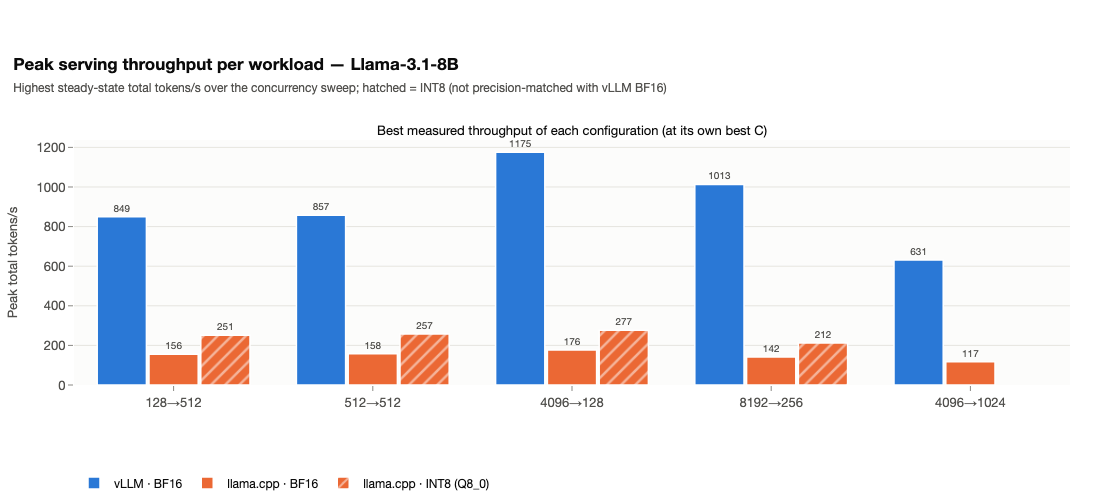

In [5]:
peak_view = summary[summary["model"] == MODEL]
fig = plots.grouped_bars(peak_view.assign(group="peak"), x="workload_shape", y="peak_total_tok_s", error=None, facet="group",
                         facet_labels={"peak": "Best measured throughput of each configuration (at its own best C)"},
                         y_title="Peak total tokens/s",
                         title=f"Peak serving throughput per workload — {registry.model_label(MODEL)}",
                         subtitle="Highest steady-state total tokens/s over the concurrency sweep; hatched = INT8 (not precision-matched with vLLM BF16)")
fig.show()
export_figure(fig, "peak_throughput_by_workload", source=NOTEBOOK,
              caption="Best measured total tokens/s of each configuration per workload (8B), each at its own best concurrency.")
export_table(summary[["model", "workload", "configuration_id", "c1_total_tok_s", "c1_tpot_s", "c1_ttft_s", "peak_total_tok_s",
                      "peak_concurrency", "peak_over_c1", "knee_concurrency", "max_concurrency", "tpot_at_peak_s",
                      "mem_total_gbs_at_peak", "max_bw_util_vs_stream"]], "curve_summary")
export_table(ratio[["model", "workload", "concurrency", "value_num", "value_den", "ratio", "ratio_rel_err"]]
             .rename(columns={"value_num": "vllm_total_tok_s", "value_den": "llama_cpp_total_tok_s"}), "backend_ratio_bf16")

## Claims behind the decision

In [6]:
vk = cross[cross["workload"].isin(["decode", "balanced"])]
claims = [
    Claim("llama.cpp is the better single-request decoder at matched precision (short prompts)",
          bool((vk["ratio_c1"] < 1).all()), f"C=1 throughput ratio {rng(vk['ratio_c1'], x, nd=2)}"),
    Claim("vLLM scales further with concurrency on every model and workload",
          bool((v_s.set_index(['model', 'workload'])['peak_over_c1'] > l_s.set_index(['model', 'workload'])['peak_over_c1']).all()),
          f"{K['vllm_peak_over_c1_short']} vs {K['llamacpp_peak_over_c1_short']} (short prompts)"),
    Claim("vLLM delivers ≥ 4× llama.cpp's throughput at the highest common C on every curve (BF16)",
          bool((cross["ratio_at_highest_common_c"] >= 4).all()), K["ratio_at_highest_common_c"]),
    Claim("vLLM's advantage holds under a per-token latency budget",
          bool(((budget_ratio["vllm"] / budget_ratio["llama_cpp"]) > 1).all()), K["throughput_ratio_tpot_budget_100ms"]),
    Claim("vLLM BF16 beats llama.cpp's fastest configuration (INT8) peak vs peak",
          bool((cross_int8 > 1).all()), K["vllm_bf16_over_llamacpp_int8_peak"]),
    Claim("More concurrency does NOT raise total memory traffic (all curves)",
          bool(traffic["traffic_falls_with_c"].all()), K["curves_traffic_falls"]),
    Claim("vLLM keeps the memory system busier than llama.cpp at equal C ≥ 8",
          bool((traffic_ratio[traffic_ratio["concurrency"] >= 8]["ratio"] > 1).all()), K["traffic_ratio_c8_plus"]),
    Claim("No configuration saturates memory bandwidth (all < 70% of STREAM)",
          bool(traffic["max_bw_util"].max() < 0.7), K["max_bw_share"]),
    Claim("The INT8 backend pair (vLLM W8A8 vs llama.cpp Q8_0) has been measured",
          bool((comparisons.backend_pairs(pts)["precision"] == "int8").any()), "pending" if not (comparisons.backend_pairs(pts)["precision"] == "int8").any() else "measured"),
]
display(claims_table(claims))

Holds,Statement,Evidence (computed)
✓,llama.cpp is the better single-request decoder at matched precision (short prompts),C=1 throughput ratio 0.77×–0.89×
✓,vLLM scales further with concurrency on every model and workload,22.9×–42.7× vs 3.2×–5.8× (short prompts)
✓,vLLM delivers ≥ 4× llama.cpp's throughput at the highest common C on every curve (BF16),4.9×–7.0×
✓,vLLM's advantage holds under a per-token latency budget,4.5×–9.7×
✓,vLLM BF16 beats llama.cpp's fastest configuration (INT8) peak vs peak,3.3×–6.1×
✓,More concurrency does NOT raise total memory traffic (all curves),100%
✓,vLLM keeps the memory system busier than llama.cpp at equal C ≥ 8,1.5×–5.4×
✓,No configuration saturates memory bandwidth (all < 70% of STREAM),65%
✗ revisit,The INT8 backend pair (vLLM W8A8 vs llama.cpp Q8_0) has been measured,pending


## Measured result

In [7]:
show(f"""
- **Single request.** At C = 1 and matched precision, vLLM ÷ llama.cpp median TPOT is {K['c1_tpot_vllm_over_llamacpp_bf16']}
  (llama.cpp faster per token on most shapes) and vLLM ÷ llama.cpp throughput on the short-prompt shapes is
  {K['c1_throughput_ratio_short_prompts']}; llama.cpp's time to first token is {K['c1_ttft_llamacpp_over_vllm_bf16']} vLLM's.
- **Concurrency.** vLLM BF16 peaks at C = {K['vllm_peak_concurrency_8b']} on {registry.model_label(MODEL)} ({K['vllm_peak_total_tok_s_8b']} total tok/s),
  llama.cpp BF16 at C = {K['llamacpp_peak_concurrency_8b']} ({K['llamacpp_peak_total_tok_s_8b']} tok/s). On short prompts vLLM reaches
  {K['vllm_peak_over_c1_short']} its C = 1 throughput, llama.cpp {K['llamacpp_peak_over_c1_short']}. vLLM catches up by
  C = {K['crossover_concurrency_short_prompts']} on short prompts, and at the highest common C delivers {K['ratio_at_highest_common_c']}
  llama.cpp's throughput (peak vs peak, 8B: {K['peak_ratio_8b']}; within a 100 ms TPOT budget: {K['throughput_ratio_tpot_budget_100ms']};
  vs llama.cpp INT8, peak vs peak: {K['vllm_bf16_over_llamacpp_int8_peak']}).
- **Mechanism.** Both servers batch; the per-token cost of a step falls {K['step_cost_drop_vllm']} over the sweep for vLLM vs
  {K['step_cost_drop_llamacpp']} for llama.cpp. vLLM's AMX busy fraction reaches {K['vllm_amx_busy_at_highest_c']} at its highest C;
  llama.cpp BF16's is {K['llamacpp_bf16_amx_busy']}.
- **Memory.** Total memory traffic is lower at the highest C than at C = 1 on {K['curves_traffic_falls']} of curves; the largest share of
  the {K['stream_sustainable_gbs']} GB/s sustainable bandwidth reached anywhere is {K['max_bw_share']}; vLLM's share falls from
  {K['vllm_bw_share_c1']} at C = 1 to {K['vllm_bw_share_highest_c']} at its highest C. At equal C ≥ 8 vLLM moves {K['traffic_ratio_c8_plus']}
  llama.cpp's traffic.
""".replace("\n    ", "\n"))


- **Single request.** At C = 1 and matched precision, vLLM ÷ llama.cpp median TPOT is 0.99×–1.33×
  (llama.cpp faster per token on most shapes) and vLLM ÷ llama.cpp throughput on the short-prompt shapes is
  0.77×–0.89×; llama.cpp's time to first token is 4.0×–9.8× vLLM's.
- **Concurrency.** vLLM BF16 peaks at C = 64–128 on Llama-3.1-8B (631–1,175 total tok/s),
  llama.cpp BF16 at C = 4–32 (117–176 tok/s). On short prompts vLLM reaches
  22.9×–42.7× its C = 1 throughput, llama.cpp 3.2×–5.8×. vLLM catches up by
  C = 2–4 on short prompts, and at the highest common C delivers 4.9×–7.0×
  llama.cpp's throughput (peak vs peak, 8B: 5.4×–7.2×; within a 100 ms TPOT budget: 4.5×–9.7×;
  vs llama.cpp INT8, peak vs peak: 3.3×–6.1×).
- **Mechanism.** Both servers batch; the per-token cost of a step falls 2.5×–43.7× over the sweep for vLLM vs
  0.9×–5.7× for llama.cpp. vLLM's AMX busy fraction reaches 9%–18% at its highest C;
  llama.cpp BF16's is 0.0%.
- **Memory.** Total memory traffic is lower at the highest C than at C = 1 on 100% of curves; the largest share of
  the 502 GB/s sustainable bandwidth reached anywhere is 65%; vLLM's share falls from
  34%–56% at C = 1 to 17%–31% at its highest C. At equal C ≥ 8 vLLM moves 1.5×–5.4×
  llama.cpp's traffic.


## Interpretation

- vLLM is a serving engine whose throughput, step rate, AMX use and memory traffic all remain responsive across
  the concurrency range; llama.cpp is an efficient single-stream engine whose per-step cost at large batch caps
  it early.
- Concurrency does not, by itself, push the memory system towards saturation: batching amortizes the weight read
  and turns serving compute-bound. Memory pressure under serving lives in (i) low-batch decode (weight streaming)
  and (ii) decode over long, growing KV caches at high C.

## Implication for the thesis

- The HBM/DDR experiments need a platform that can be driven over a wide range of concurrency and context lengths
  with throughput that responds to load, so that memory behaviour can be studied at many operating points. Only
  vLLM provides this; llama.cpp would leave most of the range flat.
- The experimental motivation "more concurrency ⇒ more memory pressure" must be refined: the HBM experiments
  should target long-KV decode at high concurrency and low-batch decode explicitly, measure memory traffic rather
  than assume it, and use short-context high-C cells as a compute-bound control.
- llama.cpp remains useful as a reference: it is the stronger single-stream decoder and a well-understood
  baseline for the low-batch, bandwidth-bound regime.

## Decision

**vLLM is selected as the primary backend** for the HBM-focused experimental campaign. The decision rests on the
precision-matched BF16 comparison and is robust to comparing peak against peak, to latency budgets and to
llama.cpp's fastest INT8 configuration. llama.cpp is retained as the comparison/reference backend.

## Pending: vLLM INT8 validation

The controlled INT8 pair (vLLM W8A8 vs llama.cpp Q8_0, both on AMX-INT8) is prepared but not measured. It tests
whether vLLM's advantage persists when llama.cpp's weight GEMMs also run on AMX. llama.cpp INT8 already plateaus at
the same concurrency as llama.cpp BF16, so the decision is not expected to change, but this is untested until the
data exist. When they do: sync, `make data`, `make notebooks`; the claims table above flips the last claim and the
INT8 pair appears in notebooks 04–08.